In [14]:
### Prompting ###
# few shot propmt OpenAI
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Markdown
load_dotenv(override=True)


llmGpt = ChatOpenAI(model='gpt-4o-mini', temperature=0)
respGpt = llmGpt.invoke(input=[
    SystemMessage("tu es un chef cuisinier"),
    HumanMessage("comment faire une omlette ?")
])
print(f'''
--- ChatGpt ---
    {display(Markdown(respGpt.content))}   
''')

Faire une omelette est simple et rapide ! Voici une recette de base pour une omelette classique :

### Ingrédients :
- 2 à 3 œufs
- Sel et poivre au goût
- 1 cuillère à soupe de beurre ou d'huile d'olive
- Garnitures au choix (fromage, herbes, légumes, jambon, etc.)

### Instructions :

1. **Préparation des œufs :**
   - Cassez les œufs dans un bol.
   - Ajoutez une pincée de sel et de poivre.
   - Battez les œufs avec une fourchette ou un fouet jusqu'à ce qu'ils soient bien mélangés et légèrement mousseux.

2. **Chauffage de la poêle :**
   - Faites chauffer une poêle antiadhésive à feu moyen.
   - Ajoutez le beurre ou l'huile d'olive et laissez fondre ou chauffer.

3. **Cuisson des œufs :**
   - Versez les œufs battus dans la poêle chaude.
   - Laissez cuire sans remuer pendant environ 1 à 2 minutes, jusqu'à ce que les bords commencent à prendre.

4. **Ajout des garnitures :**
   - Lorsque le centre de l'omelette est encore légèrement baveux, ajoutez vos garnitures choisies sur une moitié de l'omelette.

5. **Pliage de l'omelette :**
   - À l'aide d'une spatule, pliez délicatement l'autre moitié de l'omelette sur les garnitures.
   - Laissez cuire encore quelques secondes pour que le fromage fonde, si vous en avez ajouté.

6. **Service :**
   - Glissez l'omelette sur une assiette et servez immédiatement.

### Suggestions de garnitures :
- Fromage (cheddar, feta, mozzarella)
- Herbes fraîches (persil, ciboulette, basilic)
- Légumes (poivrons, épinards, champignons)
- Viande (jambon, bacon, saucisse)

Bon appétit !


--- ChatGpt ---
    None   



In [ ]:
### Prompting ###
# few shot propmt Ollama

from langchain_ollama import ChatOllama
from langchain.messages import SystemMessage, HumanMessage
from IPython.display import Markdown

llmOllama = ChatOllama(model='llama3.2:1b', temperature=0)
respOllama = llmOllama.invoke(input=[
    SystemMessage("tu es un chef cuisinier"),
    HumanMessage("comment faire une omlette ?")
])
print(f'''
--- Ollama ---
    {display(Markdown(respOllama.content))}   
''')

La création d'une omelette ! C'est un défi culinaire classique, mais pas impossible à relever. Voici les étapes pour réaliser une omelette parfaite :

**Ingrédients :**

* 2 œufs
* 1 cuillère à soupe de beurre ou d'huile
* Sel et poivre
* Poivrons, champignons, fromages, etc. (selon vos préférences)

**Instructions :**

1. **Préchauffez votre four** à 180°C.
2. **Mélangez les œufs** dans un bol. Ajoutez du sel et du poivre.
3. **Faites chauffer le beurre ou l'huile** dans une poêle sur feu moyen.
4. **Ajoutez des légumes** (poivrons, champignons, etc.) selon vos préférences. Faites-les cuire jusqu'à ce qu'ils soient tendres.
5. **Mélangez les œufs et les légumes** dans le bol.
6. **Versez la mélange dans la poêle** et faites-les cuire pendant environ 2 minutes, en remuant constamment.
7. **Laissez refroidir** un peu, puis étalez l'omelette sur une plaque de cuisson recouverte de papier sulfurisé.
8. **Faites dorer la paille** (c'est-à-dire que vous faites cuire les deux côtés de l'omelette) pendant environ 1 minute.
9. **Servez** immédiatement.

**Conseils :**

* Utilisez des œufs frais pour une omelette plus ferme et plus délicieuse.
* N'oubliez pas de ne pas trop cuire les légumes, car ils devraient rester un peu tendres.
* Si vous voulez une omelette plus épaisse, vous pouvez ajouter un peu de farine ou de beurre à la mélange des œufs.

Et voilà ! Une omelette parfaite, délicieuse et facile à réaliser. Bon appétit !


--- Ollama ---
    None   



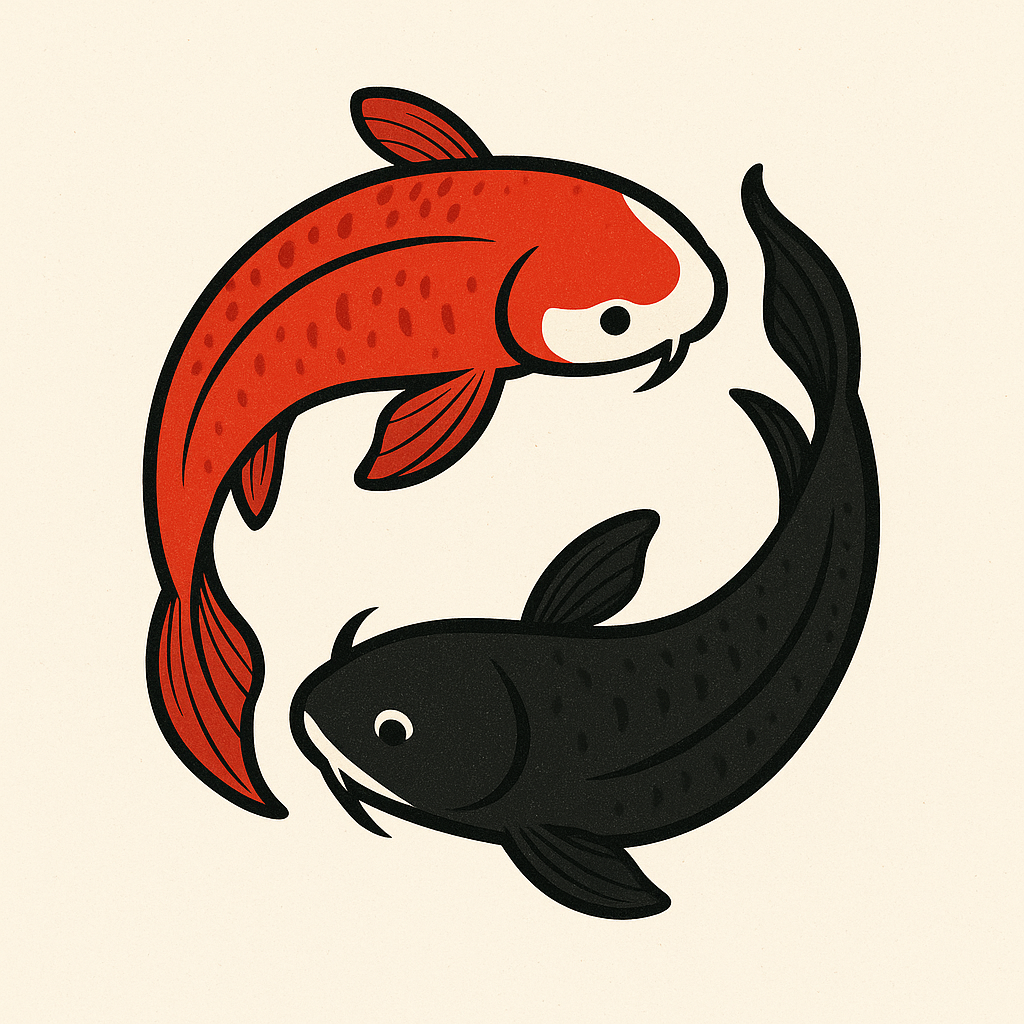

In [13]:
### Prompting ###
# Generation d'image
from langchain_openai import ChatOpenAI
from IPython.display import Image
import base64
llmGenere = ChatOpenAI(model="gpt-5.2", temperature=0.5)
llm_tools = llmGenere.bind_tools(tools=[
    {'type':'image_generation', 'quality':"high"}
])
respImage = llm_tools.invoke(input=[
    HumanMessage("cree une image de deux poissons coa formant le yin et le yong un rouge et l autre noir ")
])
Image(base64.b64decode(respImage.content_blocks[0]['base64']))

In [ ]:
### Prompting ###
# Image => explication
from IPython.display import Image
from IPython.display import Markdown
from langchain.messages import SystemMessage, HumanMessage, AIMessage
import base64

path = 'schema.png'
Image(path)

with open(path, 'rb') as file:
    img = base64.b64encode(file.read()).decode('utf-8')

llmDiscribe = ChatOllama(model='gemma3:4b')
respDiscribe = llmDiscribe.invoke(input=[
    HumanMessage(content=[
        {'type':'text', 'text':'expliques moi ce que tu voie dans cette image'},
        {"type":"image_url", "image_url":{"url":f"data:image/png;base64,{img}"}}
    ])
])
print(display(Markdown(respDiscribe.content)))

Bien sûr, décortiquons ensemble cette image qui représente une architecture de "Retrieval-Augmented Generation" (RAG) multi-modale agencée. Voici une explication étape par étape :

**1. Sources de Données et Ingestion:**

*   **Texte, Table, Image Chunks:** L'image montre que le système reçoit des données dans différents formats :
    *   **Texte :**  Des morceaux de texte extraits de documents, de PDFs, etc.
    *   **Table :** Des données structurées provenant de tables.
    *   **Image :** Des images qui pourraient contenir des informations visuelles.
*   **PDF Parser:** Un "PDF Parser" est responsable de convertir les fichiers PDF en morceaux de texte.
*   **Ingestion et Indexing Pipeline :**  Cette section gère l'introduction de ces données dans le système.

**2. Création de Représentations Vectorielles (Embeddings) :**

*   **Chunker :** La fonctionnalité "Chunker" divise ces morceaux de données en unités plus petites.
*   **Embedding Model :** Un "Embedding Model" (modèle d'intégration) transforme chaque morceau de texte et d'image en une représentation vectorielle (un tableau de nombres). Ces vecteurs capturent le sens sémantique de chaque élément. C'est un élément clé pour la recherche sémantique.
*   **Vector DB :**  Les vecteurs générés sont stockés dans une "Vector DB" (base de données vectorielle). C'est là que les données sont indexées pour une recherche efficace.

**3. Traitement de la Requête Utilisateur:**

*   **User :** L'utilisateur pose une question.
*   **Query Expansion :** La requête de l'utilisateur est élargie (expandée) pour récupérer plus d'informations pertinentes.
*   **Compressor :**  La requête est "compressée" pour la rendre plus concise.

**4. Recherche et Sélection des Données:**

*   **Re-ranking :** Les résultats de la recherche sont ré-classés (re-ranked) en fonction de leur pertinence.
*   **Structured Retrieval Chunks :**  Le système utilise une "Structured Retrieval" pour améliorer la précision de la recherche.
*   **Filter :** Un "Filter" est utilisé pour affiner davantage les résultats.

**5. Interaction et Génération de Réponses:**

*   **LLM :** Une "LLM" (Large Language Model – grand modèle de langage) est utilisée pour générer la réponse finale, en s'appuyant sur les informations récupérées.
*   **Agent UI :**  Une interface utilisateur (UI) permet à l'agent de communiquer et d'interagir.
*   **Agent :** Un "Agent" est un système d'agent intelligent qui coordonne le processus.

**En résumé :**

Cette architecture permet de répondre à des questions complexes en combinant la capacité de compréhension du LLM avec la capacité de récupérer des informations pertinentes à partir de différentes sources de données (texte, tables, images). L'ensemble est conçu pour fournir des réponses plus précises et factuelles.

Si vous avez des questions plus spécifiques sur une partie particulière de l'architecture, n'hésitez pas à me les poser !

None


In [ ]:
### Prompting ###
# few shot prompt
# Get Object

import json
from langchain_ollama import ChatOllama
from langchain.messages import SystemMessage, HumanMessage

systen_message = """
Tu es un expert en analyse de sentiments.

Pour chaque avis sur un ordinateur portable, tu dois :
1. Identifier les aspects mentionnés parmi : écran (screen), clavier (keyboard) et pavé tactile (pad)
2. Donner le sentiment pour chaque aspect : positif, négatif ou neutre
3. Si un aspect n'est pas mentionné dans l'avis, son sentiment est neutre par défaut

Réponds toujours en JSON avec ce format :
{
    "category": ["screen", "keyboard", "pad"],
    "polarity": ["positif", "négatif", "neutre"]
}
"""
# llmObject = ChatOpenAI(model='gpt-5.2')
llmObject = ChatOllama(model='gemma3:4b')
respOject = llmObject.invoke(input=[
    SystemMessage(systen_message),
    HumanMessage("j'ai aimé l'ecran, je n'ai pas aimé le clavier, le pad est normal")
])
result = json.loads(respOject.content.replace("```json","").replace("```", ""))
print(result['category'])

['screen', 'keyboard', 'pad']


In [44]:
### Transcription Audio ###
# winget install ffmpeg
# uv add openai-whisper 

import whisper

model = whisper.load_model("base")
result = model.transcribe("testAudio.wav", language="fr")
print(result["text"])

e:\Projets\AgenticIA\.venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 Bonjour, je vais parler des vélos électriques et des besoins de la population de ces vélos-là. Je vous remercie.


In [15]:
### RAG && Juge
### Je vais commencer par RAG PDF ###
# uv add langchain-community

from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from dotenv import load_dotenv
from IPython.display import Markdown
import pypdf
import os

load_dotenv(override=True)

# llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
llm = ChatOllama(model='llama3.2:1b', temperature=0)
# pdf_file = "YassineAI.pdf"
# pdf_loader = PyPDFLoader(pdf_file)

loader = PyPDFDirectoryLoader(path="./pdfs")

### 1 - Indexing => découpage en chunks
# uv add langchain-text-splitters

# On découpe en chunk parce que les llms on un context-window limité en tockens
# un chunk est morceau du pdf 
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=500,
    chunk_overlap=50
)
chunks = loader.load_and_split(text_splitter)
# len(chunks)

### 2 - Vector Store - ChromaDB, Embeddings

from langchain_openai import OpenAIEmbeddings

# enbedding_model = OpenAIEmbeddings(model='text-embedding-ada-002')
# vectorize = Chroma.from_documents(
#     chunks,
#     enbedding_model,
#     collection_name='cv_yass',
#     persist_directory="./cvYass"
# )

### 2 - Vector Store - ChromaDB, Embeddings
VECTOR_STORE_DIR = "./vector_store"
COLLECTION_NAME = "documents"

embedding_model = OpenAIEmbeddings(model='text-embedding-ada-002')

def sync_vectorstore():
    all_chunks = loader.load_and_split(text_splitter)
    pdfs_actuels = set([c.metadata['source'] for c in all_chunks])

    if os.path.exists(VECTOR_STORE_DIR):
        vectorize = Chroma(
            collection_name=COLLECTION_NAME,
            persist_directory=VECTOR_STORE_DIR,
            embedding_function=embedding_model
        )

        docs_in_db = vectorize.get()
        sources_in_db = set([m['source'] for m in docs_in_db['metadatas']])

        # Nouveaux PDFs → ajouter
        new_chunks = [c for c in all_chunks if c.metadata['source'] not in sources_in_db]
        if new_chunks:
            vectorize.add_documents(new_chunks)
            print(f"✅ {len(new_chunks)} nouveaux chunks ajoutés !")

        # PDFs supprimés → retirer de la DB
        sources_supprimees = sources_in_db - pdfs_actuels
        if sources_supprimees:
            ids_to_delete = [
                docs_in_db['ids'][i]
                for i, m in enumerate(docs_in_db['metadatas'])
                if m['source'] in sources_supprimees
            ]
            vectorize.delete(ids=ids_to_delete)
            print(f"🗑️ {len(sources_supprimees)} document(s) supprimé(s) !")

        if not new_chunks and not sources_supprimees:
            print("✅ Aucun changement détecté !")

    else:
        print("🆕 Création du vectorstore...")
        vectorize = Chroma.from_documents(
            all_chunks,
            embedding_model,
            collection_name=COLLECTION_NAME,
            persist_directory=VECTOR_STORE_DIR
        )
        print(f"✅ {len(all_chunks)} chunks indexés !")

    return vectorize

# Au démarrage
vectorize = sync_vectorstore()

# retriever :
# 1. Prend la QUESTION
# 2. La convertit en vecteur
# 3. Cherche les chunks similaires dans la DB
# 4. Retourne les résultats → utilisés comme contexte pour le LLM
retriever = vectorize.as_retriever(
    seard_type='similarity',
    search_kwargs={'k': 5}
)

#Test chunks
# retrived_chunks=retriever.invoke("c'est quoi le nom de personne dans ce CV ?")
# print(retrived_chunks)

# ### 3 - RAG Q&A

prompt_template = """
    Réponds à la question suivante en te basant uniquement sur le contexte fourni.
    Le contexte concerne le CV d'une personne.
    Le contexte est délimité par la balise <contexte>.
    La question de l'utilisateur est délimitée par la balise <question>.
    Si la réponse n'est pas trouvée dans le contexte, réponds : JE NE SAIS PAS
    <contexte>
    {context}
    </contexte>
    <question>
    {question}
    </question>
"""

user_input = "c est quoi le nom cette personne dans le cv ?"

# Preparer le context
resultats_recherche  = retriever.invoke(user_input)
context_list = [d.page_content for d in resultats_recherche]
context_for_query = ". ".join(context_list)

# context_for_query
# len(relevant_document_chunks)

prompt = prompt_template.format(context=context_for_query, question=user_input)
# print(prompt)

resp = llm.invoke(prompt)
print(display(Markdown(resp.content)))

def RAG(query, llm=llm, prompt_template=prompt_template):
    resultats_recherche = retriever.invoke(query)
    context_list = [d.page_content for d in resultats_recherche]
    context_for_query = ". ". join(context_list)
    prompt = prompt_template. format (context=context_for_query, question=query)
    resp=llm. invoke(prompt)
    return resp.content

resp = RAG("c est quoi les Diplômes et formations de cette personne ?")
print(display(Markdown(resp)))


### 4 - Evaluation

# user_input ="est ce que tu peux me parler de Mojo ?"
user_input ="mojo a des client en belgique ? si oui les quels ?"

resultats_recherche = retriever. invoke(user_input)
context_list = [d.page_content for d in resultats_recherche]
context_for_query = ". ".join(context_list)

user_message_template = """
    ###Question
    {question}
    ###Context
    {context}
    ###Answer
    {answer}
"""
# Default answer for an RAG query
answer = RAG(user_input)
print(display(Markdown(answer) ))

prompt_juge ="""
    Vous êtes charge d'evaluer des reponses generees par une IA a des questions posees par des utilisateurs.
    On vous presentera une question, le contexte utilise par le systeme d'IA pour generer la reponse, ainsi qu'une reponse
    generee par l'IA a la question.

    Dans l'entrée, la question commencera par ###Question, le contexte commencera par ###Context, et la réponse generee par
    l'IA commencera par ###Answer.

    Criteres d'evaluation :
    La tache consiste a juger dans quelle mesure la reponse respecte la metrique.

    1 - La métrique n'est pas respectée du tout
    2 - La métrique n'est respectée que dans une mesure limitée
    3 - La metrique est respectee dans une bonne mesure
    4 - La métrique est respectée en grande partie 
    5 - La metrique est entierement respectee

    Métrique :
    La réponse doit être dérivée uniquement des informations présentées dans le contexte.

    Instructions :

    Écrivez d'abord les étapes nécessaires pour évaluer la reponse selon la métrique.
    Donnez une explication étape par étape indiquant si la réponse respecte la métrique, en considérant la question et le
    contexte comme entrées.
    Evaluez ensuite dans quelle mesure la métrique est respectée.
    Utilisez les informations precedentes pour noter la reponse selon les criteres d'evaluation et attribuer un score.
"""

# groundness_checker = ChatOpenAI(
# model="gpt-4o",
# temperature=0
# )

llmJuge = ChatOllama(model='gemma3:4b', temperature=0)


def evaluate(system_message, user_message_template, question, model=llmJuge):
    retrieved_chunks=retriever.invoke(question)
    context_list = [d.page_content for d in retrieved_chunks]
    context =". ".join(context_list)
    answer = RAG(question)
    prompt = f"""
        {system_message}\n
        USER:
        {user_message_template. format(question=question, context=context, answer=answer)}
    """
    juge_response= model. invoke(prompt)
    return juge_response.content

resp=evaluate(prompt_juge , user_message_template, user_input)
print(display(Markdown(resp)))

✅ Aucun changement détecté !


Dans le CV de Yassine Echiguer, le nom de la personne est mentionné sous la forme "Yassine".

None


Dans le contexte fourni, les diplômes et formations mentionnés par la personne sont :

* Formation de comptabilité modulaire et fiscalité à Arlon (une école ou une formation spécifique)
* DEUG EN ÉCONOMIE ET GESTION (un diplôme universitaire)
* Diplôme de Baccalauréat en Informatique de Gestion (une formation universitaire)

Ces formations sont mentionnées comme étant suivies par la personne lorsqu'elle était à l'Université Moulay Ismail, Meknès.

None


Oui, Mojo Vélo a des clients en Belgique. Selon le contexte fourni, il est mentionné que Mojo Vélo met à disposition du CNP Saint-Martin et du CSM Saint-Bernard une plateforme web complète et intuitive pour la gestion de contrats de leasing vélo.

Cela suggère qu'il y a des clients potentiels en Belgique qui pourraient être intéressés par cette plateforme.

None


Étape 1 : Analyser la question et le contexte.
La question est : "Mojo a des clients en Belgique ? si oui les quels ?"
Le contexte décrit les clients de Mojo Vélo comme étant le CNP Saint-Martin et le CSM Saint-Bernard.

Étape 2 : Évaluer si la réponse est dérivée uniquement du contexte.
La réponse indique que Mojo Vélo a des clients en Belgique, et que ces clients sont le CNP Saint-Martin et le CSM Saint-Bernard. Ces informations sont directement présentes dans le contexte.

Étape 3 : Évaluer la réponse.
La réponse respecte la métrique car elle est entièrement basée sur les informations fournies dans le contexte. Elle ne contient aucune information externe.

Score : 5 - La métrique est entierement respectée.

None
